In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Hyperparameters (Updated for TTUR) ---
num_epochs = 2000
batch_size = 128
latent_dim = 2

# TTUR: Different learning rates for Generator and Discriminator
lr_G = 0.0001 # Slower Generator
lr_D = 0.0004 # Faster Discriminator

I0000 00:00:1780059971.407492  192626 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780059971.429452  192626 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def get_real_samples(batch_size):
    x = np.random.uniform(-1, 1, (batch_size, 1))
    y = x ** 2
    
    # DATA JITTER: Add a tiny amount of noise to the real data
    # This prevents the Discriminator from memorizing a perfect line
    x += np.random.normal(0, 0.05, x.shape)
    y += np.random.normal(0, 0.05, y.shape)
    
    return np.hstack((x, y)).astype(np.float32) 

# --- 2. Architecture (Warning-Free) ---
def build_generator():
    model = models.Sequential([
        layers.Input(shape=(latent_dim,)), 
        layers.Dense(64),
        layers.LeakyReLU(negative_slope=0.2), # Updated here
        layers.Dense(64),
        layers.LeakyReLU(negative_slope=0.2), # Updated here
        layers.Dense(2) 
    ])
    return model

def build_discriminator():
    model = models.Sequential([
        layers.Input(shape=(2,)), 
        layers.Dense(64),
        layers.LeakyReLU(negative_slope=0.2), # Updated here
        layers.Dense(64),
        layers.LeakyReLU(negative_slope=0.2), # Updated here
        layers.Dense(1, activation='sigmoid')
    ])
    return model

Starting Training...
Epoch [100/2000] | D Loss: 1.3286 | G Loss: 0.7812


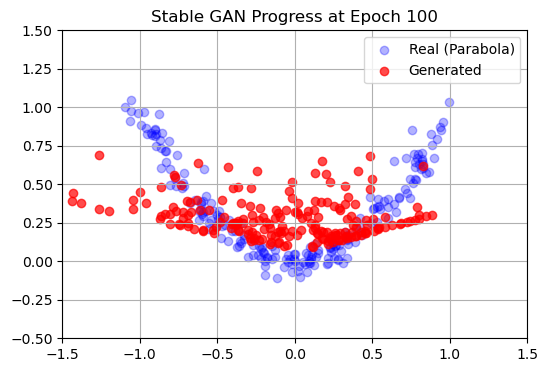

Epoch [200/2000] | D Loss: 1.3657 | G Loss: 0.9117


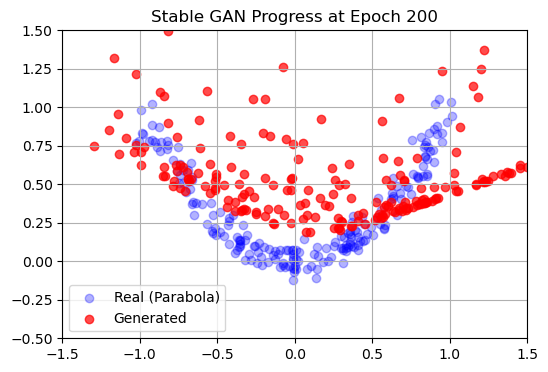

Epoch [300/2000] | D Loss: 1.3259 | G Loss: 0.8023


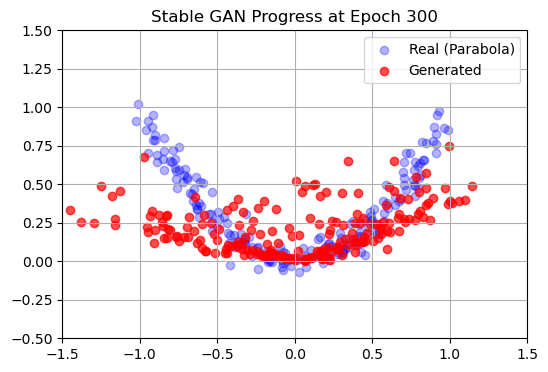

Epoch [400/2000] | D Loss: 1.3358 | G Loss: 0.8200


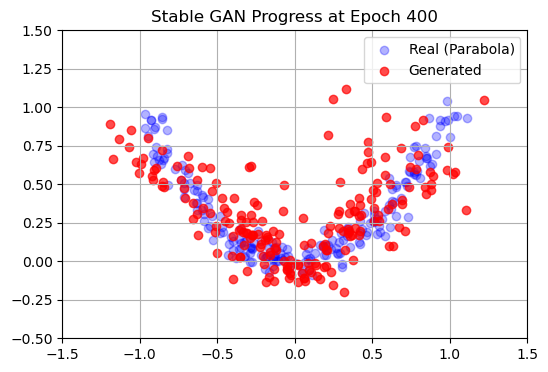

Epoch [500/2000] | D Loss: 1.3495 | G Loss: 0.8094


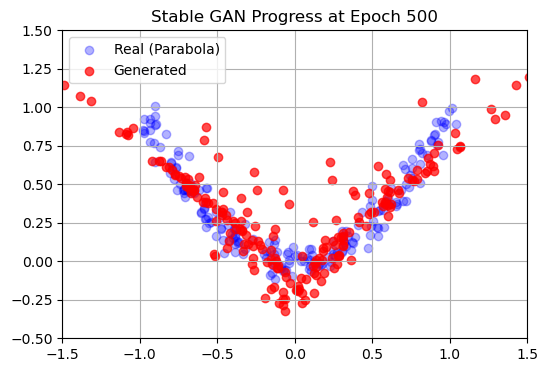

Epoch [600/2000] | D Loss: 1.3647 | G Loss: 0.8220


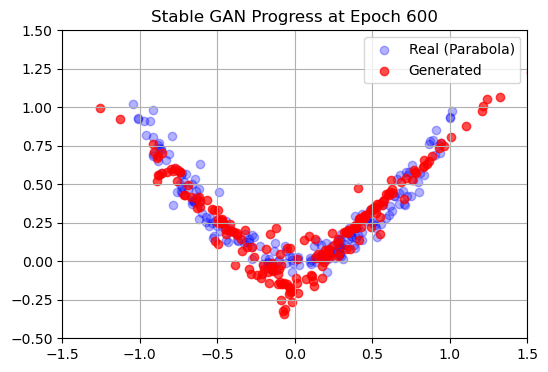

Epoch [700/2000] | D Loss: 1.3670 | G Loss: 0.8128


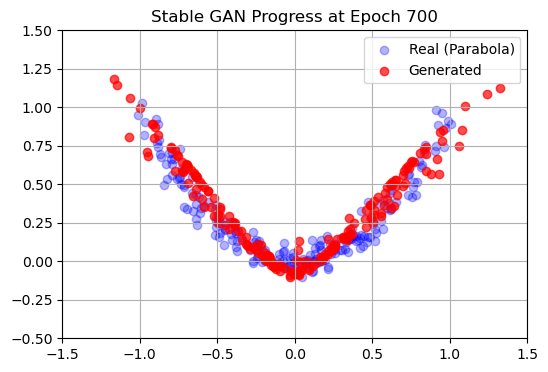

Epoch [800/2000] | D Loss: 1.3616 | G Loss: 0.7967


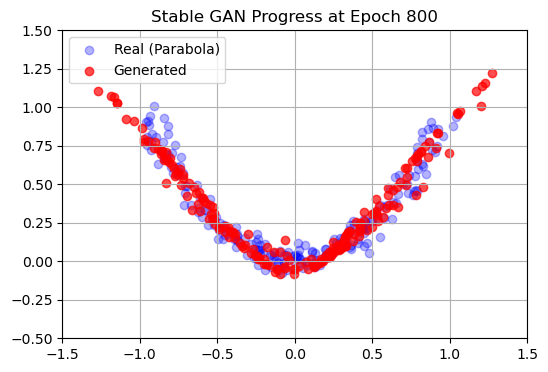

Epoch [900/2000] | D Loss: 1.3696 | G Loss: 0.8014


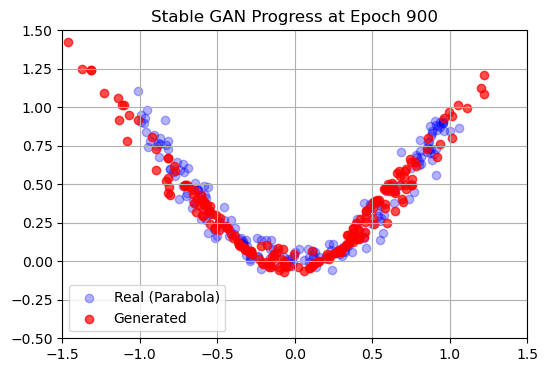

Epoch [1000/2000] | D Loss: 1.3724 | G Loss: 0.8101


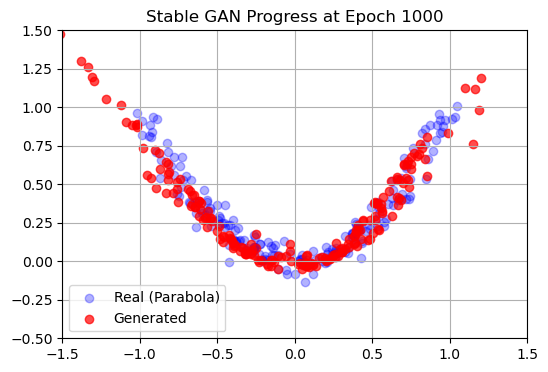

Epoch [1100/2000] | D Loss: 1.3739 | G Loss: 0.7871


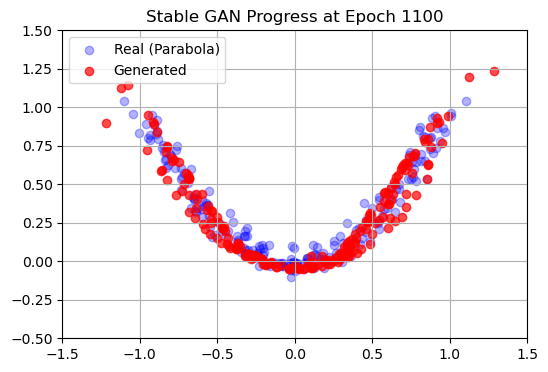

Epoch [1200/2000] | D Loss: 1.3625 | G Loss: 0.8023


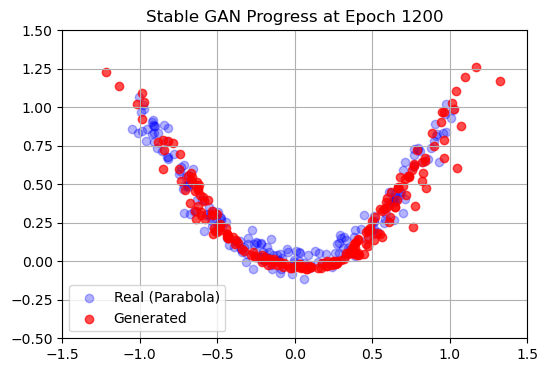

Epoch [1300/2000] | D Loss: 1.3495 | G Loss: 0.8108


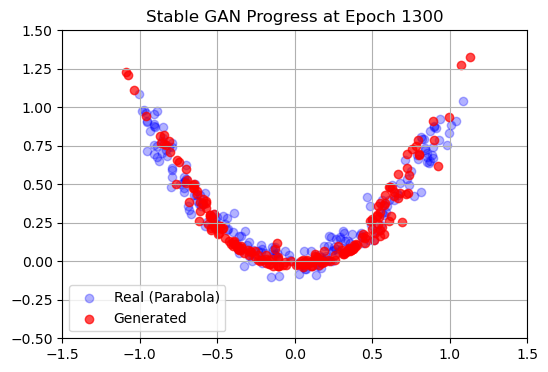

Epoch [1400/2000] | D Loss: 1.3451 | G Loss: 0.8091


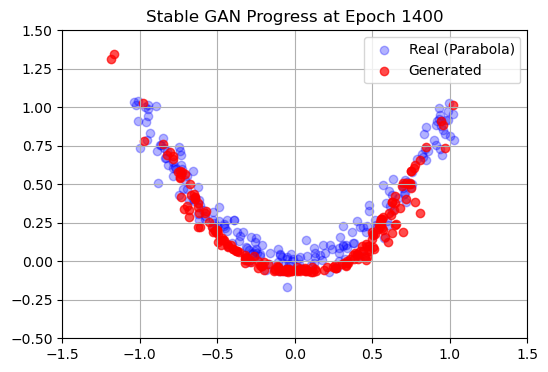

Epoch [1500/2000] | D Loss: 1.3901 | G Loss: 0.7550


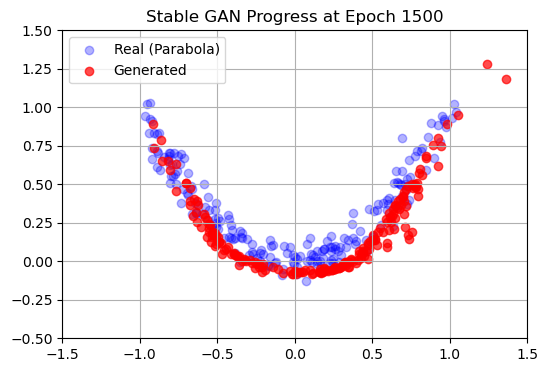

Epoch [1600/2000] | D Loss: 1.3386 | G Loss: 0.8374


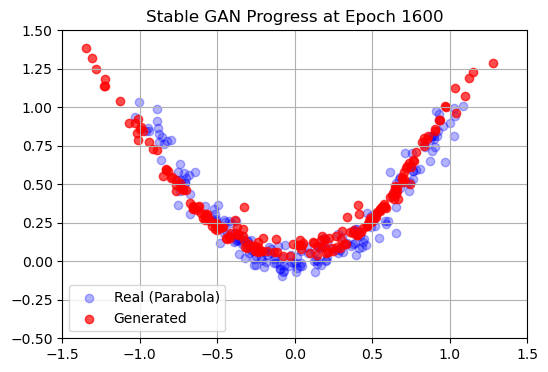

Epoch [1700/2000] | D Loss: 1.3780 | G Loss: 0.8384


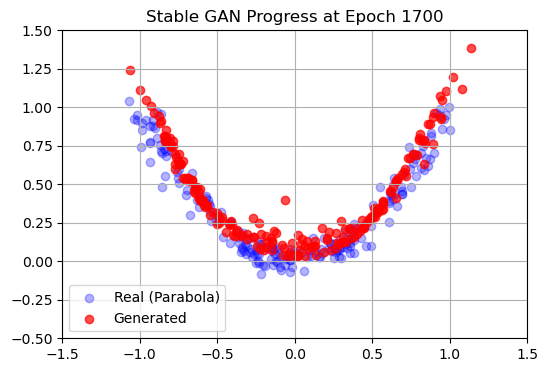

Epoch [1800/2000] | D Loss: 1.3694 | G Loss: 0.7911


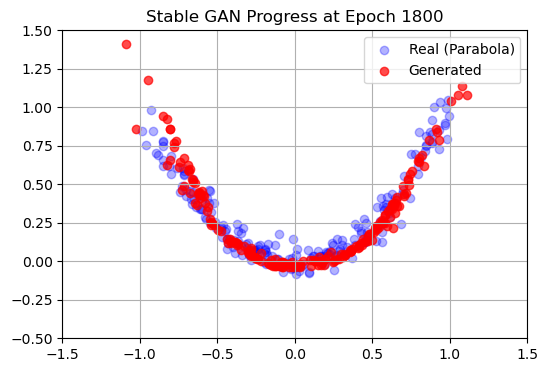

Epoch [1900/2000] | D Loss: 1.3789 | G Loss: 0.7769


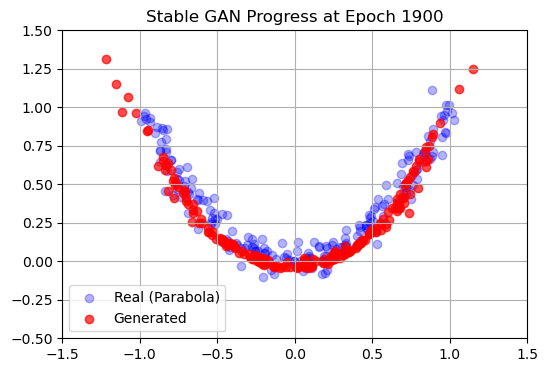

Epoch [2000/2000] | D Loss: 1.3723 | G Loss: 0.8045


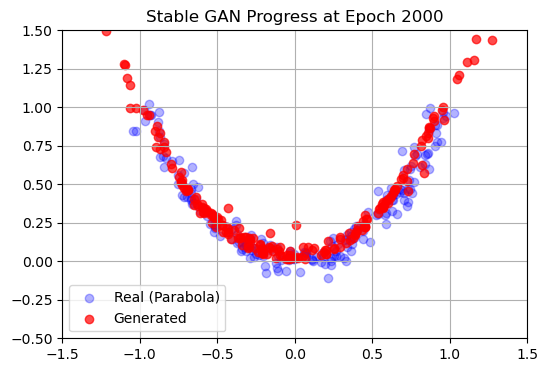

In [3]:
generator = build_generator()
discriminator = build_discriminator()

# --- 3. Setup Manual Optimizers ---
# Notice: No .compile() and no combined GAN model!
cross_entropy = tf.keras.losses.BinaryCrossentropy()
optimizer_G = optimizers.Adam(learning_rate=lr_G)
optimizer_D = optimizers.Adam(learning_rate=lr_D)

# --- 4. Custom Training Loop (GradientTape) ---
print("Starting Training...")
for epoch in range(num_epochs):
    
    # Generate Data
    real_data = get_real_samples(batch_size)
    noise = tf.random.normal([batch_size, latent_dim])
    
    # ---------------------
    #  Train Discriminator
    # ---------------------
    with tf.GradientTape() as tape_D:
        fake_data = generator(noise, training=False)
        real_output = discriminator(real_data, training=True)
        fake_output = discriminator(fake_data, training=True)
        
        # Calculate loss with LABEL SMOOTHING (0.9 instead of 1.0)
        d_loss_real = cross_entropy(tf.ones_like(real_output) * 0.9, real_output)
        d_loss_fake = cross_entropy(tf.zeros_like(fake_output), fake_output)
        d_loss = d_loss_real + d_loss_fake
        
    grads_D = tape_D.gradient(d_loss, discriminator.trainable_variables)
    optimizer_D.apply_gradients(zip(grads_D, discriminator.trainable_variables))
    
    # -----------------
    #  Train Generator
    # -----------------
    noise = tf.random.normal([batch_size, latent_dim])
    
    with tf.GradientTape() as tape_G:
        fake_data = generator(noise, training=True)
        fake_output = discriminator(fake_data, training=False)
        
        g_loss = cross_entropy(tf.ones_like(fake_output), fake_output)
        
    grads_G = tape_G.gradient(g_loss, generator.trainable_variables)
    optimizer_G.apply_gradients(zip(grads_G, generator.trainable_variables))

    # -------------------------
    #  Plot Progress over Time
    # -------------------------
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | D Loss: {d_loss:.4f} | G Loss: {g_loss:.4f}")
        
        test_noise = tf.random.normal([200, latent_dim])
        current_generated_points = generator(test_noise, training=False).numpy()
        current_real_points = get_real_samples(200)

        plt.figure(figsize=(6, 4))
        plt.scatter(current_real_points[:, 0], current_real_points[:, 1], color='blue', alpha=0.3, label='Real (Parabola)')
        plt.scatter(current_generated_points[:, 0], current_generated_points[:, 1], color='red', alpha=0.7, label='Generated')
        plt.title(f"Stable GAN Progress at Epoch {epoch+1}")
        plt.xlim([-1.5, 1.5])
        plt.ylim([-0.5, 1.5])
        plt.legend()
        plt.grid(True)
        plt.show()

Training Complete! Generating final plot...


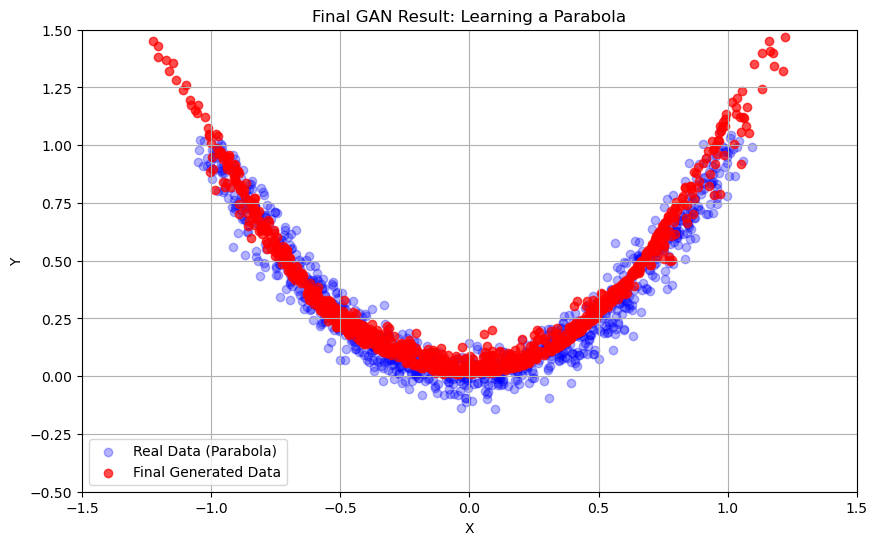

In [4]:
# --- 5. Final Visualization ---
print("Training Complete! Generating final plot...")

# Generate a larger set of fake data to see the final shape
final_noise = tf.random.normal([1000, latent_dim])
final_generated_points = generator(final_noise, training=False).numpy()

# Get a larger set of real data for comparison
final_real_points = get_real_samples(1000)

# Create the final high-resolution plot
plt.figure(figsize=(10, 6))
plt.scatter(final_real_points[:, 0], final_real_points[:, 1], color='blue', alpha=0.3, label='Real Data (Parabola)')
plt.scatter(final_generated_points[:, 0], final_generated_points[:, 1], color='red', alpha=0.7, label='Final Generated Data')
plt.title("Final GAN Result: Learning a Parabola")
plt.xlabel("X")
plt.ylabel("Y")

# Keep axis limits consistent
plt.xlim([-1.5, 1.5])
plt.ylim([-0.5, 1.5])

plt.legend()
plt.grid(True)
plt.show()